# 第五章 · 刻画未来成长因子

## 研报核心观点

历史高增长 ≠ 未来高增长。
需要：
1. **用当前财务指标预测未来盈利增速**（§5.2）
2. **分析师预期变化**反映市场对未来盈利的判断（§5.3）

## 本章内容

| 子因子 | 数据需求 | 状态 |
|--------|---------|------|
| 回归预测净利润增速（§5.2）| 当前财务指标 | ✅ 已实现 |
| 分析师盈利预测上调（§5.3）| Wind 一致预期 | ❌ 待数据 |

## 研报提到的 7 个预测特征（§5.2）

> ROA、应计项目、投资强度、ROE 同比变化、EP、经营性净资产增长率、外部融资

## 预期效果

研报指出回归预测净利润因子能显著提升选股能力。

## 1. 环境设置

In [1]:
import sys
import importlib
sys.path.insert(0, '.')
import Factor_Library as FL
importlib.reload(FL)

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('环境就绪（内核已刷新）')

环境就绪（内核已刷新）


## 2. 数据准备

In [2]:
# 加载基础 PIT 字段
pit_profit = FL.load_pit_financial('net_profit_parent_company')
pit_revenue = FL.load_pit_financial('operating_revenue')
pit_assets = FL.load_pit_financial('total_assets')
pit_equity = FL.load_pit_financial('equity_parent_company')
pit_cfo = FL.load_pit_financial('cash_flow_from_operating_activities')

# 累计 → 单季度
sq_profit, _ = FL.to_single_quarter(pit_profit, 'net_profit_parent_company')
sq_revenue, _ = FL.to_single_quarter(pit_revenue, 'operating_revenue')
sq_assets, _ = FL.to_single_quarter(pit_assets, 'total_assets')
sq_equity, _ = FL.to_single_quarter(pit_equity, 'equity_parent_company')
sq_cfo, _ = FL.to_single_quarter(pit_cfo, 'cash_flow_from_operating_activities')

# 行情 + 行业
close_price = FL.load_daily('close')
returns_next_month = FL.next_month_return(close_price, months=1)
industry_dummy = FL.load_industry_dummy()

print(f'净利润: {sq_profit.shape}')

净利润: (5514, 41)


## 3. 构造预测特征

7 个特征，实现 6 个（外部融资需要发行股+借款数据，未独立下载）：

| 特征 | 公式 |
|------|------|
| ROA | 净利润 / 总资产 |
| 应计项目 | 净利润 - CFO |
| 投资强度 | 总资产同比增速 |
| ROE 同比变化 | ROE_t - ROE_{t-4} |
| EP | 净利润 / 净资产 |
| 经营性净资产增长率 | 总资产同比增速 |


In [3]:
def calc_features(sq_profit, sq_revenue, sq_assets, sq_equity, sq_cfo, lag=0):
    '''构造 6 个预测特征。'''
    features = {}

    # ROA = 净利润 / 总资产
    features['ROA'] = sq_profit / sq_assets.replace(0, np.nan)

    # 应计项目 = 净利润 - CFO
    features['应计项目'] = sq_profit.shift(lag, axis=1) - sq_cfo.shift(lag, axis=1)

    # 投资强度 = 同比的同比（yoy_yoy_growth）
    yoy = sq_assets / sq_assets.shift(4 + lag, axis=1) - 1
    features['投资强度'] = yoy / yoy.shift(4 + lag, axis=1) - 1

    # ROE 同比变化
    roe = sq_profit / sq_equity.replace(0, np.nan)
    features['ROE同比变化'] = roe - roe.shift(4 + lag, axis=1)

    # EP = 净利润 / 净资产
    features['EP'] = sq_profit / sq_equity.replace(0, np.nan)

    # 经营性净资产增长率 ≈ 同比的同比（yoy_yoy_growth）
    yoy_assets = sq_assets / sq_assets.shift(4 + lag, axis=1) - 1
    features['经营性净资产增长率'] = yoy_assets / yoy_assets.shift(4 + lag, axis=1) - 1

    return features


# 构造特征
features = calc_features(sq_profit, sq_revenue, sq_assets, sq_equity, sq_cfo)
print(f'特征数: {len(features)}')
for name, df in features.items():
    print(f'  {name}: {df.shape}')

特征数: 6
  ROA: (5514, 41)
  应计项目: (5514, 41)
  投资强度: (5514, 41)
  ROE同比变化: (5514, 41)
  EP: (5514, 41)
  经营性净资产增长率: (5514, 41)


## 4. 预测目标：未来 4 个季度累计净利润同比增速

用过去 4 季度累计 vs 未来 4 季度累计。


In [4]:
def calc_future_growth(sq_profit, n_forward=4, n_history=4, lag=1):
    """未来增速。lag=1：避免 look-ahead。"""

    '''未来 n_forward 个季度累计净利润同比增速。'''
    # 滚动 n_history 季度求和 → 当前 TTM
    ttm = sq_profit.T.rolling(window=n_history, min_periods=n_history).sum().T

    # 未来 TTM（向前移动 n_forward）
    future_ttm = ttm.shift(-n_forward, axis=1)

    # 未来同比增速
    future_growth = future_ttm / ttm.replace(0, np.nan) - 1
    return future_growth


# 计算未来增速
future_growth = calc_future_growth(sq_profit, n_forward=4, n_history=4)
print(f'未来增速: {future_growth.shape}')
print(future_growth.iloc[:5, -8:])

未来增速: (5514, 41)


               2024-09-30  2024-12-31  2025-03-31  2025-06-30  2025-09-30  \
order_book_id                                                               
000001.XSHE    -15.787234   -0.036980   -1.510766   -1.818632         NaN   
000002.XSHE     -0.680893   -0.366039   -1.049973    0.434856         NaN   
000003.XSHE           NaN         NaN         NaN         NaN         NaN   
000004.XSHE           NaN         NaN         NaN         NaN         NaN   
000005.XSHE           NaN         NaN         NaN         NaN         NaN   

               2025-12-31  2026-03-31  2026-06-30  
order_book_id                                      
000001.XSHE           NaN         NaN         NaN  
000002.XSHE           NaN         NaN         NaN  
000003.XSHE           NaN         NaN         NaN  
000004.XSHE           NaN         NaN         NaN  
000005.XSHE           NaN         NaN         NaN  


## 5. 横截面 Ridge 回归

In [5]:
def cross_sectional_ridge(X_dict, target, alpha=1.0, min_samples=50):
    '''每个季度横截面 Ridge 回归。

    X_dict: {特征名: DataFrame (date × stock)}
    target: DataFrame (date × stock), 未来增速目标

    Returns:
        pred_df: 预测值（=因子值）
        coef_history: 每期回归系数（特征重要性）
    '''
    # 公共日期和股票
    first = list(X_dict.values())[0]
    common_dates = first.columns
    common_stocks = first.index
    for f in X_dict.values():
        common_dates = common_dates.intersection(f.columns)
        common_stocks = common_stocks.intersection(f.index)

    pred_dict = {}
    coef_history = []

    for date in common_dates:
        X_list = []
        valid_stocks = set(common_stocks)

        for name, df in X_dict.items():
            vals = df[date].reindex(common_stocks)
            valid_stocks &= set(vals.dropna().index)
            X_list.append(vals)

        y = target[date].reindex(common_stocks)
        valid_stocks = list(valid_stocks & set(y.dropna().index))
        if len(valid_stocks) < min_samples:
            continue

        # 构造特征矩阵
        X = pd.DataFrame({
            name: df[date][valid_stocks].values
            for name, df in X_dict.items()
        })

        # 标准化
        X_norm = (X - X.mean()) / X.std().replace(0, 1)
        y_norm = y[valid_stocks] - y[valid_stocks].mean()

        # Ridge 回归
        try:
            model = Ridge(alpha=alpha)
            model.fit(X_norm.fillna(0), y_norm.fillna(0))
            y_pred = model.predict(X_norm.fillna(0))
            pred_dict[date] = pd.Series(y_pred, index=valid_stocks)
            coef_history.append({
                'date': date,
                **{n: c for n, c in zip(X_dict.keys(), model.coef_)}
            })
        except Exception:
            pass

    pred_df = pd.DataFrame(pred_dict).T
    pred_df.index = pd.to_datetime(pred_df.index)
    return pred_df, coef_history


# 跑回归
pred_growth, coef_history = cross_sectional_ridge(features, future_growth, alpha=1.0)
print(f'预测因子: {pred_growth.shape}')

预测因子: (29, 3589)


## 6. 单因子测试

回归预测净利润增速: IC=-0.0299, ICIR=-0.6138
多空年化: -0.0759


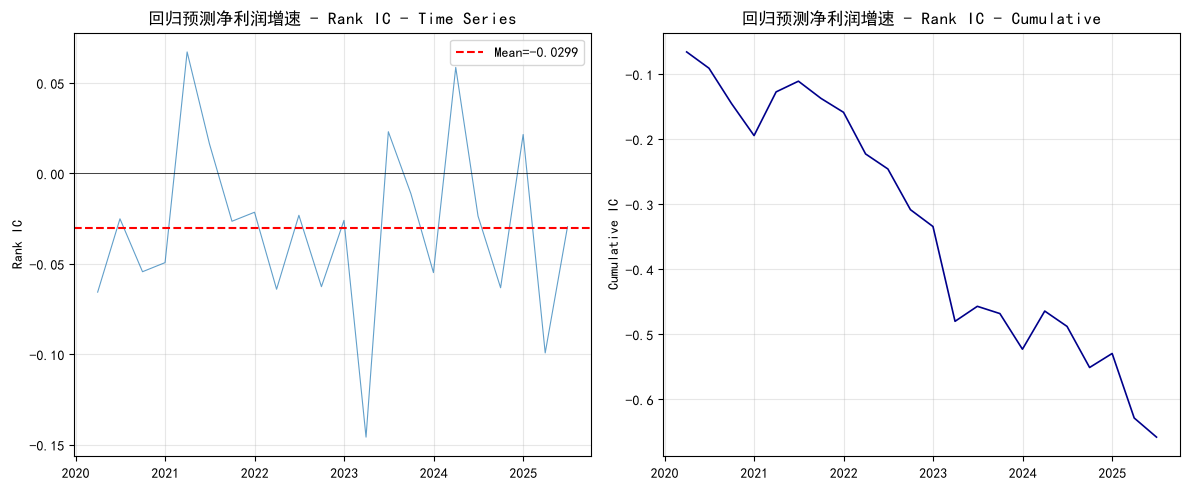

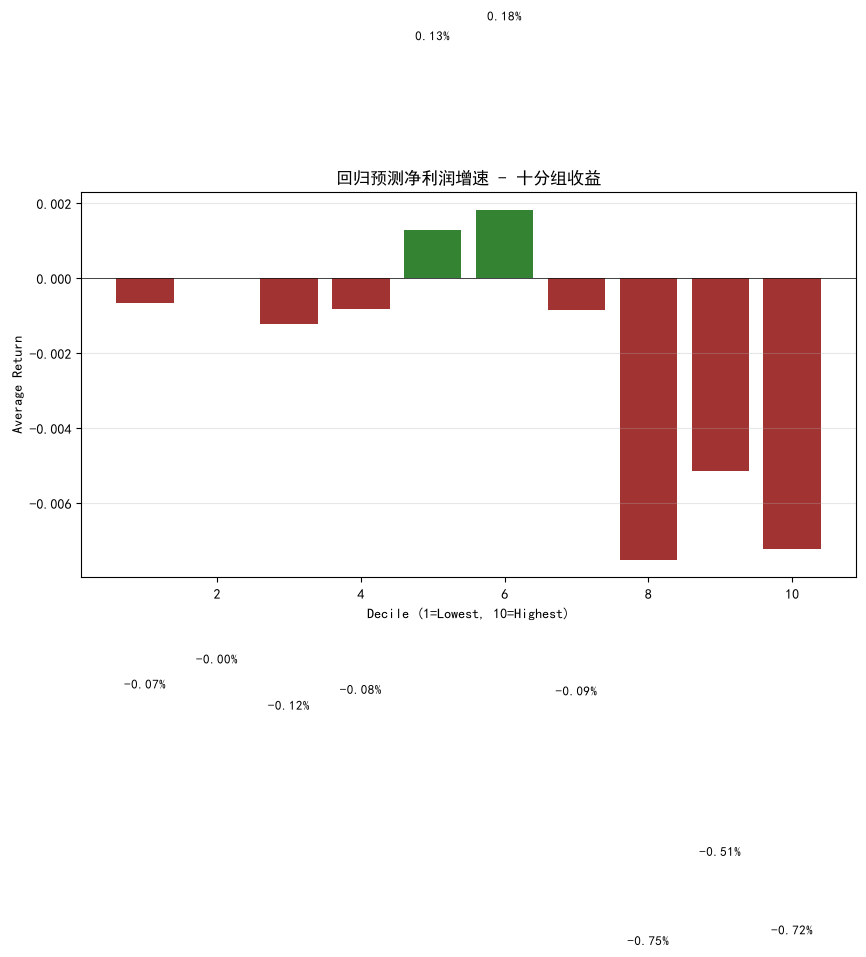

In [6]:
# 测试因子
ic_pred = FL.rank_ic_test(pred_growth, returns_next_month)
stats_p = FL.calc_ic_stats(ic_pred)
decile_p = FL.decile_test(pred_growth, returns_next_month)

print(f'回归预测净利润增速: IC={stats_p["mean"]:.4f}, ICIR={stats_p["icir"]:.4f}')

if decile_p:
    ls = decile_p[max(decile_p)] - decile_p[min(decile_p)]
    ann = (1 + ls) ** 12 - 1
    print(f'多空年化: {ann:.4f}')

# 绘图
fig = FL.plot_ic_curve(ic_pred, title='回归预测净利润增速 - Rank IC')
plt.show()
fig = FL.plot_decile_bars(decile_p, title='回归预测净利润增速 - 十分组收益')
plt.show()

## 7. 特征重要性

特征系数均值（标准化后）：
EP           0.772356
经营性净资产增长率    0.252921
投资强度         0.252921
ROA          0.034929
应计项目        -0.287296
ROE同比变化     -0.801884
dtype: float64

特征系数标准差：
ROA          0.463321
应计项目         1.191101
投资强度         1.439141
ROE同比变化      2.612825
EP           2.638278
经营性净资产增长率    1.439141
dtype: float64


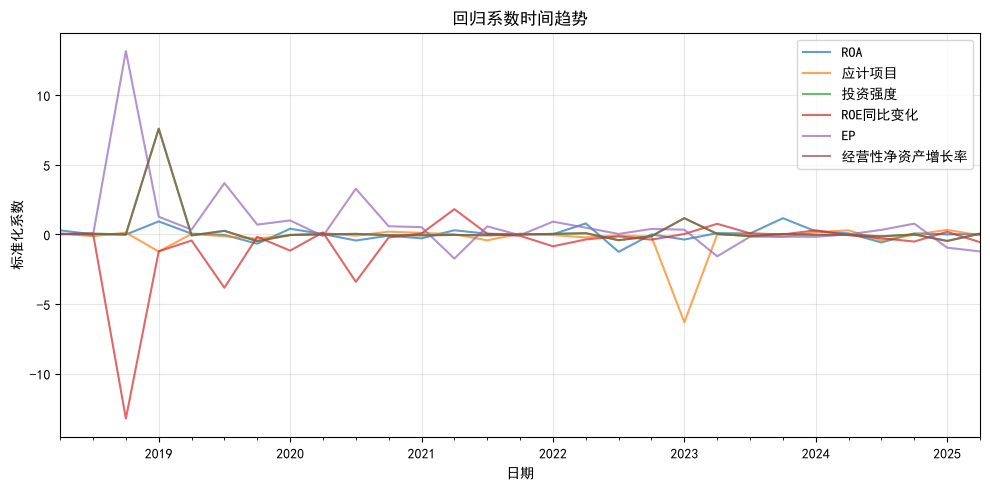

In [7]:
coef_df = pd.DataFrame(coef_history).set_index('date') if 'date' in pd.DataFrame(coef_history).columns else pd.DataFrame(coef_history)

if 'date' not in coef_df.columns and len(coef_df) > 0:
    coef_df.index = pd.to_datetime(coef_df.index)

print('特征系数均值（标准化后）：')
print(coef_df.mean(numeric_only=True).sort_values(ascending=False))

print()
print('特征系数标准差：')
print(coef_df.std(numeric_only=True))

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
for col in coef_df.columns:
    coef_df[col].plot(ax=ax, label=col, alpha=0.7)
ax.set_title('回归系数时间趋势')
ax.set_xlabel('日期')
ax.set_ylabel('标准化系数')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 综合因子

由于本章只有一个因子（回归预测），综合 = 标准化后自身。

研报中"未来成长综合"会与回归预测上调因子等权平均，但 5.3 需要分析师数据。


In [8]:
# 标准化作为综合因子
pred_normalized = FL.normalize_factor(pred_growth)
ic_pred_n = FL.rank_ic_test(pred_normalized, returns_next_month)
stats_pn = FL.calc_ic_stats(ic_pred_n)
print(f'回归预测（标准化后）: IC={stats_pn["mean"]:.4f}, ICIR={stats_pn["icir"]:.4f}')

回归预测（标准化后）: IC=-0.0297, ICIR=-0.6133


## 9. TODO: 分析师盈利预测上调因子

### 数据需求

需要 Wind 一致预期数据：
- `net_profit_fy0` 本财年净利润预测
- `net_profit_fy1` 下财年净利润预测

### 因子逻辑

1. 每个分析师对单只股票的净利润预测
2. 计算每月**所有分析师预测的平均值**
3. 看该平均值是否**上调** → 即因子值

### 简化代理（无 consensus 数据时）

可以用我们的净利润同比增速（**同比上修** 作为代理），效果稍弱但可用。